In [1]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Explainability
import shap

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LOAD DATASET

df = pd.read_csv("application_train.csv")

# Display first few rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# DATA CLEANING

# Convert negative employment days to positive
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].abs()

# Convert birth days to age
df["AGE"] = df["DAYS_BIRTH"].abs() / 365

# Remove original DAYS_BIRTH column
df.drop(columns=["DAYS_BIRTH"], inplace=True)

# EDUCATION GROUPING

education_mapping = {

    "Lower secondary":
    "Primary Education",

    "Secondary / secondary special":
    "Secondary Education",

    "Incomplete higher":
    "Secondary Education",

    "Higher education":
    "Higher Education",

    "Academic degree":
    "Higher Education"
}

df["NAME_EDUCATION_TYPE"] = (
    df["NAME_EDUCATION_TYPE"]
    .map(education_mapping)
    .fillna("No Formal Education")
)

# OCCUPATION GROUPING

occupation_mapping = {

    "Laborers":
    "Laborer",

    "Drivers":
    "Driver",

    "Sales staff":
    "Vendor / Trader",

    "Core staff":
    "Self-Employed",

    "Managers":
    "Small Business Owner",

    "Cooking staff":
    "Food Service Worker",

    "Cleaning staff":
    "Domestic Worker",

    "Security staff":
    "Security Worker",

    "Medicine staff":
    "Healthcare Worker",

    "Accountants":
    "Self-Employed",

    "Private service staff":
    "Domestic Worker",

    "Low-skill Laborers":
    "Laborer",

    "Waiters/barmen staff":
    "Food Service Worker",

    "Drivers":
    "Driver",

    "Realty agents":
    "Vendor / Trader",

    "Secretaries":
    "Self-Employed",

    "HR staff":
    "Self-Employed",

    "IT staff":
    "Self-Employed",

    "High skill tech staff":
    "Self-Employed",

    "Medicine staff":
    "Healthcare Worker",

    "Cooking staff":
    "Food Service Worker"
}

df["OCCUPATION_TYPE"] = (
    df["OCCUPATION_TYPE"]
    .map(occupation_mapping)
    .fillna("Other")
)


# Fill missing numeric values
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill missing categorical values
df.fillna("Unknown", inplace=True)

# Clip extreme outliers
df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=500000)
df["AMT_CREDIT"] = df["AMT_CREDIT"].clip(upper=2000000)

In [4]:
# FEATURE ENGINEERING

# Income volatility estimation
df["MinIncome"] = 0.75 * df["AMT_INCOME_TOTAL"]
df["MaxIncome"] = 1.10 * df["AMT_INCOME_TOTAL"]

df["DEVS"] = (
    (df["MaxIncome"] - df["MinIncome"])
    / df["MaxIncome"]
)

# Dependency Pressure Index (DPI)
income_earners = (
    df["CNT_FAM_MEMBERS"] - df["CNT_CHILDREN"]
).clip(lower=1)

df["DPI"] = (
    df["CNT_CHILDREN"]
    / (income_earners + 1)
)

# Loan Service Ratio (LSR)
df["LSR"] = (
    df["AMT_ANNUITY"]
    / df["AMT_INCOME_TOTAL"]
)

# Additional financial ratio features
df["LOAN_TO_INCOME"] = (
    df["AMT_CREDIT"]
    / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_TO_INCOME"] = (
    df["AMT_ANNUITY"]
    / df["AMT_INCOME_TOTAL"]
)

df["GOODS_TO_CREDIT"] = (
    df["AMT_GOODS_PRICE"]
    / df["AMT_CREDIT"]
)

df["INCOME_PER_PERSON"] = (
    df["AMT_INCOME_TOTAL"]
    / df["CNT_FAM_MEMBERS"]
)

df["CREDIT_PER_PERSON"] = (
    df["AMT_CREDIT"]
    / df["CNT_FAM_MEMBERS"]
)

# Preview engineered features
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,MinIncome,MaxIncome,DEVS,DPI,LSR,LOAN_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_CREDIT,INCOME_PER_PERSON,CREDIT_PER_PERSON
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,151875.0,222750.0,0.318182,0.0,0.121978,2.007889,0.121978,0.863262,202500.0,406597.50
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,202500.0,297000.0,0.318182,0.0,0.132217,4.790750,0.132217,0.873211,135000.0,646751.25
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,50625.0,74250.0,0.318182,0.0,0.100000,2.000000,0.100000,1.000000,67500.0,135000.00
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,101250.0,148500.0,0.318182,0.0,0.219900,2.316167,0.219900,0.949845,67500.0,156341.25
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,91125.0,133650.0,0.318182,0.0,0.179963,4.222222,0.179963,1.000000,121500.0,513000.00


In [5]:
# DATA PREPROCESSING

# Define features and target
X = df.drop(columns=["TARGET", "MinIncome", "MaxIncome"])
y = df["TARGET"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [6]:
# HANDLE CLASS IMBALANCE

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Scale Pos Weight:", scale_pos_weight)



# MODEL EVALUATION FUNCTION

def evaluate_model(name, y_test, y_pred, y_prob):

    auc = roc_auc_score(y_test, y_prob)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("AUC Score:", round(auc, 4))
    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

Scale Pos Weight: 11.38710976837865


In [7]:
# MODEL 1 - LOGISTIC REGRESSION

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression AUC:",
      roc_auc_score(y_test, y_prob_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Logistic Regression AUC: 0.7491259182881821
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [8]:
# MODEL 2 - RANDOM FOREST

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest AUC:",
      roc_auc_score(y_test, y_prob_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest AUC: 0.734635180352816
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     56538
           1       0.17      0.60      0.26      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.67      0.55     61503
weighted avg       0.89      0.73      0.79     61503



In [9]:
# MODEL 3 - CALIBRATED XGBOOST

from sklearn.calibration import CalibratedClassifierCV

# Base XGBoost model
xgb_base = xgb.XGBClassifier(

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    eval_metric="auc",
    random_state=42

)

# Pipeline
xgb_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),
    ("model", xgb_base)

])

# Calibrated model
xgb_model = CalibratedClassifierCV(

    estimator=xgb_pipeline,
    method="sigmoid",
    cv=3

)


# TRAIN MODEL

xgb_model.fit(
    X_train,
    y_train
)


# PREDICTIONS

y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]


# EVALUATION

print(
    "Calibrated XGBoost AUC:",
    roc_auc_score(y_test, y_prob_xgb)
)

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

Calibrated XGBoost AUC: 0.7589480853220055
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.51      0.06      0.10      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.53      0.53     61503
weighted avg       0.89      0.92      0.89     61503



In [10]:
# CROSS VALIDATION

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("\nMean Cross Validation AUC:",
      round(scores.mean(), 4))


Mean Cross Validation AUC: 0.755


In [11]:
# MODEL COMPARISON

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],

    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "Recall (Defaulters)": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["recall"]
    ],

    "Precision (Defaulters)": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["precision"]
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
    
})

print("\nModel Comparison:")
comparison_df



Model Comparison:


,Model,AUC,Recall (Defaulters),Precision (Defaulters),Accuracy
0,Logistic Regression,0.749126,0.676133,0.161355,0.690161
1,Random Forest,0.734635,0.595972,0.167620,0.728469
2,XGBoost,0.758948,0.055186,0.508349,0.919419


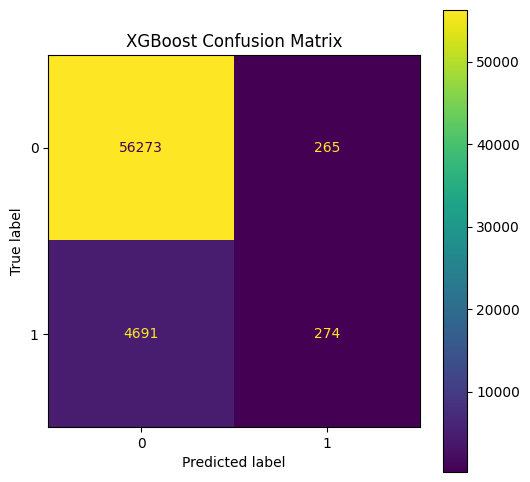

In [12]:
# CONFUSION MATRICES

fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    ax=ax
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [13]:
# PREPARE DATA FOR SHAP

# Extract calibrated pipeline
calibrated_pipeline = xgb_model.estimator

# Extract trained XGBoost model
xgb_clf = calibrated_pipeline.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Sample for SHAP
X_shap = X_test_transformed[:50]

# Extract OneHotEncoder
ohe = preprocessor.named_transformers_["cat"]

# Encoded categorical feature names
encoded_cat_features = ohe.get_feature_names_out(
    categorical_features
)

# Final feature names
final_feature_names = np.concatenate([
    numeric_features,
    encoded_cat_features
])

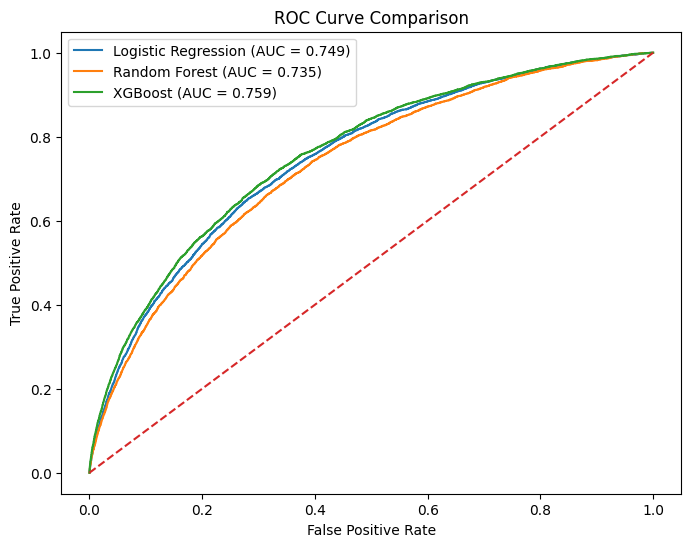

In [14]:
# ROC CURVE COMPARISON

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Create one figure
plt.figure(figsize=(8, 6))

# Plot all ROC curves on same graph
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

# Diagonal reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

# Legend
plt.legend()

# Show plot
plt.show()

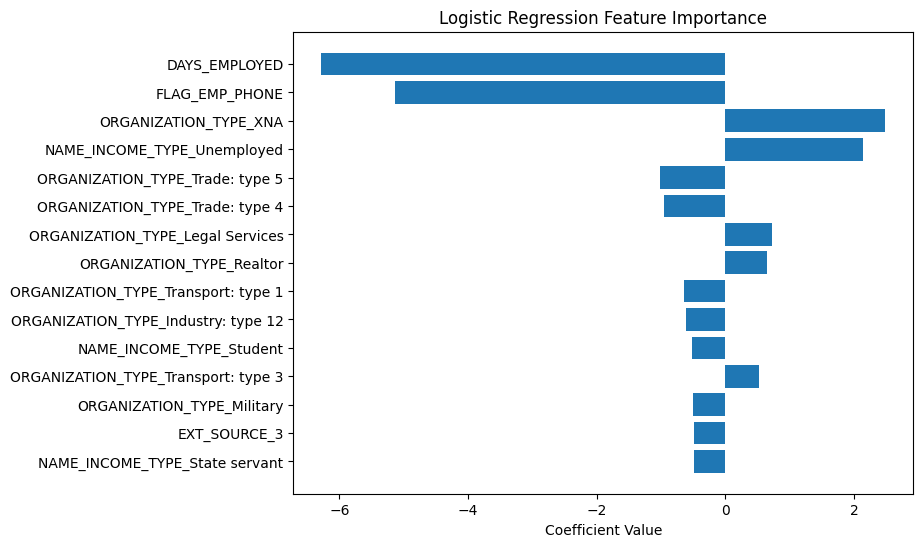

In [15]:
# LOGISTIC REGRESSION FEATURE IMPORTANCE

lr_clf = lr_model.named_steps["model"]

coefficients = lr_clf.coef_[0]

lr_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient": coefficients
})

lr_importance["AbsCoefficient"] = (
    lr_importance["Coefficient"].abs()
)

lr_importance = lr_importance.sort_values(
    "AbsCoefficient",
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(8, 6))

plt.barh(
    lr_importance["Feature"],
    lr_importance["Coefficient"]
)

plt.xlabel("Coefficient Value")

plt.title(
    "Logistic Regression Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

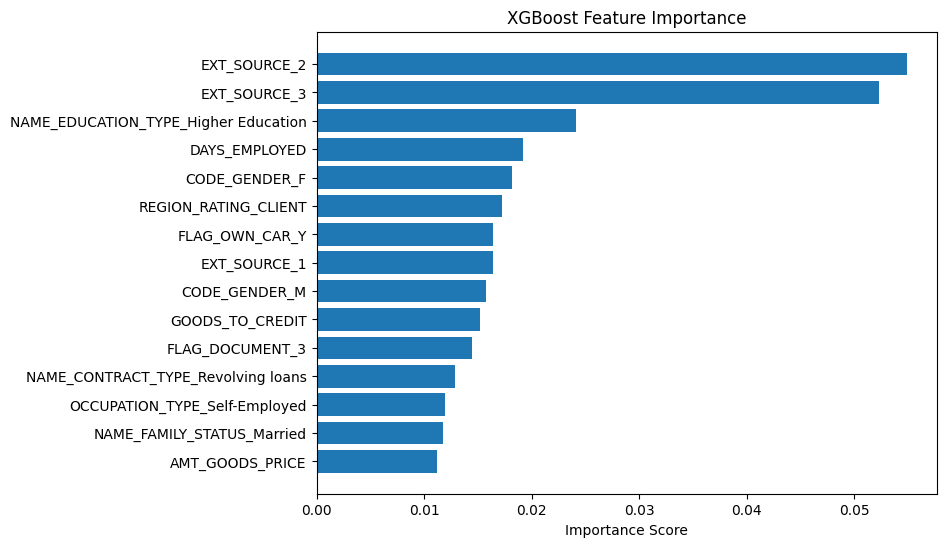

In [16]:
# XGBOOST FEATURE IMPORTANCE

# Extract first calibrated model
fitted_pipeline = (
    xgb_model.calibrated_classifiers_[0]
    .estimator
)

# Extract trained XGBoost model
xgb_clf = fitted_pipeline.named_steps["model"]

# Feature importance
xgb_importance = (
    xgb_clf.feature_importances_
)

xgb_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": xgb_importance
})

xgb_importance_df = (
    xgb_importance_df.sort_values(
        "Importance",
        ascending=False
    ).head(15)
)

# Plot
plt.figure(figsize=(8, 6))

plt.barh(
    xgb_importance_df["Feature"],
    xgb_importance_df["Importance"]
)

plt.xlabel("Importance Score")

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

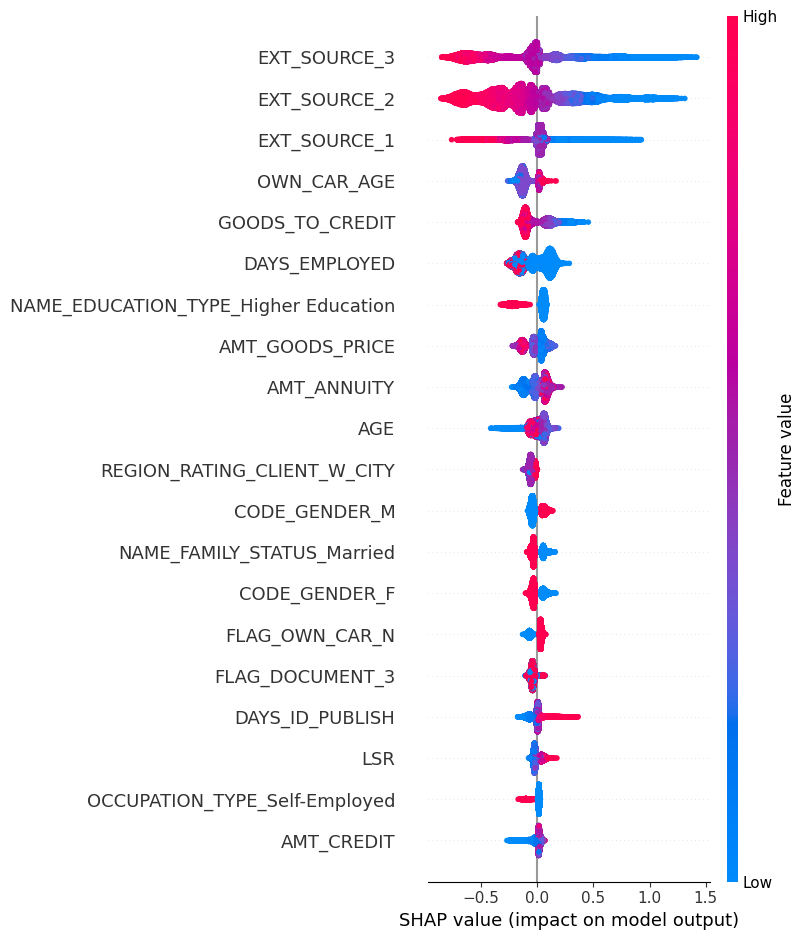

In [17]:
# SHAP EXPLAINABILITY

# Extract trained XGBoost model
fitted_pipeline = (
    xgb_model.calibrated_classifiers_[0]
    .estimator
)

xgb_clf = fitted_pipeline.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Get categorical feature names
ohe = preprocessor.named_transformers_["cat"]

encoded_cat_features = (
    ohe.get_feature_names_out(
        categorical_features
    )
)

# Final feature names
final_feature_names = np.concatenate([
    numeric_features,
    encoded_cat_features
])

# Create SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_clf)

# Generate SHAP values
shap_values_xgb = explainer_xgb.shap_values(
    X_test_transformed
)

# SHAP summary plot
shap.summary_plot(
    shap_values_xgb,
    X_test_transformed,
    feature_names=final_feature_names
)

In [18]:
# GET FEATURE NAMES

feature_names = (
    preprocessor.get_feature_names_out()
)


# CREATE SHAP EXPLAINER

explainer = shap.TreeExplainer(
    xgb_clf
)


# GENERATE SHAP VALUES

shap_values = explainer.shap_values(
    X_test_transformed
)



In [20]:

# CALCULATE GLOBAL FEATURE IMPORTANCE

feature_importance = np.abs(
    shap_values
).mean(axis=0)


# CREATE FEATURE IMPORTANCE DATAFRAME

global_shap_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": feature_importance

})


# CLEAN FEATURE NAMES

global_shap_df["Feature"] = (
    global_shap_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)


# OPTIONAL FEATURE REMOVAL
# (Remove weak / less interpretable features)

global_shap_df = global_shap_df[
    ~global_shap_df["Feature"].str.contains(
        "EXT_SOURCE",
        case=False,
        na=False
    )
]

global_shap_df = global_shap_df[
    ~global_shap_df["Feature"].isin([
        "DAYS_ID_PUBLISH",
        "DAYS_REGISTRATION"
    ])
]


# SORT FEATURES BY IMPORTANCE

global_shap_df = global_shap_df.sort_values(
    by="Importance",
    ascending=False
)


# DISPLAY TOP FEATURES

print("\nTop Influential Features")
print("------------------------")

print(
    global_shap_df.head(10)
)


# GLOBAL INTERPRETATION

print("\nGlobal Interpretation:")
print(
    "The model primarily relies on "
    "repayment burden, income stability, "
    "employment duration, and financial "
    "capacity-related variables when "
    "predicting borrower default risk."
)



Top Influential Features
------------------------
                                  Feature  Importance
10                            OWN_CAR_AGE    0.115608
110                       GOODS_TO_CREDIT    0.114595
7                           DAYS_EMPLOYED    0.111974
138  NAME_EDUCATION_TYPE_Higher Education    0.096531
5                         AMT_GOODS_PRICE    0.073198
4                             AMT_ANNUITY    0.071079
104                                   AGE    0.054313
19            REGION_RATING_CLIENT_W_CITY    0.051266
116                         CODE_GENDER_M    0.049403
142            NAME_FAMILY_STATUS_Married    0.048955

Global Interpretation:
The model primarily relies on repayment burden, income stability, employment duration, and financial capacity-related variables when predicting borrower default risk.


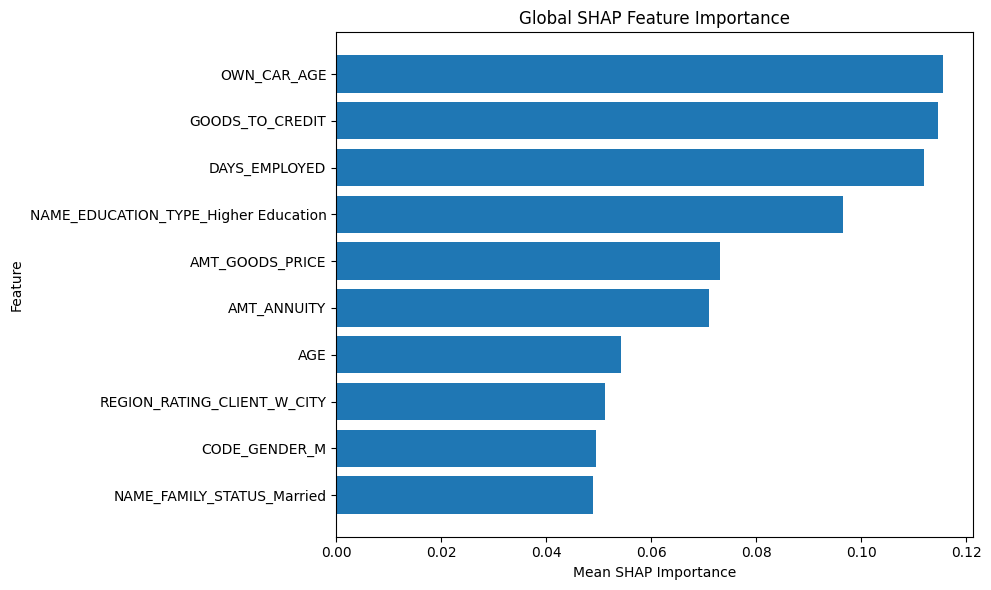

In [21]:
# GLOBAL SHAP BAR PLOT

top_plot = global_shap_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_plot["Feature"][::-1],
    top_plot["Importance"][::-1]
)

plt.xlabel("Mean SHAP Importance")
plt.ylabel("Feature")

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()
plt.show()



In [22]:
explainer_xgb = shap.TreeExplainer(xgb_clf)
shap_values_xgb = explainer_xgb.shap_values(X_shap)


In [23]:
# CREDIT RISK PREDICTION FUNCTION

def predict_credit_risk(input_df):
    
    prob = xgb_model.predict_proba(input_df)[:, 1]
    return prob


In [24]:
# SAMPLE BORROWER INPUT

input_df = pd.DataFrame([{
    "AMT_INCOME_TOTAL": 250000,
    "AMT_CREDIT": 500000,
    "AMT_ANNUITY": 15000,
    "AMT_GOODS_PRICE": 480000,
    "CNT_CHILDREN": 2,
    "CNT_FAM_MEMBERS": 4,
    "DAYS_EMPLOYED": 100,
    "AGE": 35,
    "NAME_FAMILY_STATUS": "Married",
    "NAME_EDUCATION_TYPE": "Secondary Education",
    "OCCUPATION_TYPE": "Laborers",
    "DEVS": 0.32,
    "DPI": 0.67,
    "LSR": 0.06
}])


In [25]:
# FEATURE ENGINEERING FOR INPUT DATA

input_df["LOAN_TO_INCOME"] = (
    input_df["AMT_CREDIT"]
    / input_df["AMT_INCOME_TOTAL"]
)

input_df["ANNUITY_TO_INCOME"] = (
    input_df["AMT_ANNUITY"]
    / input_df["AMT_INCOME_TOTAL"]
)

input_df["GOODS_TO_CREDIT"] = (
    input_df["AMT_GOODS_PRICE"]
    / input_df["AMT_CREDIT"]
)

input_df["INCOME_PER_PERSON"] = (
    input_df["AMT_INCOME_TOTAL"]
    / input_df["CNT_FAM_MEMBERS"]
)

input_df["CREDIT_PER_PERSON"] = (
    input_df["AMT_CREDIT"]
    / input_df["CNT_FAM_MEMBERS"]
)


# HANDLE MISSING FEATURES

# Add missing columns automatically
for col in X.columns:

    if col not in input_df.columns:

        if X[col].dtype == "object":
            input_df[col] = "Unknown"

        else:
            input_df[col] = 0


# Ensure correct column order
input_df = input_df[X.columns]




C:\Users\HP\AppData\Local\Temp\ipykernel_14748\16071684.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[col] = 0
C:\Users\HP\AppData\Local\Temp\ipykernel_14748\16071684.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[col] = 0
C:\Users\HP\AppData\Local\Temp\ipykernel_14748\16071684.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. 

In [26]:
# SHAP EXPLANATION FOR INPUT BORROWER

# Extract trained XGBoost model
fitted_pipeline = (
    xgb_model.calibrated_classifiers_[0]
    .estimator
)

xgb_clf = fitted_pipeline.named_steps["model"]

# Transform borrower input using trained preprocessor
input_df_transformed = preprocessor.transform(input_df)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_clf)

# Generate SHAP values for borrower
shap_values = explainer.shap_values(input_df_transformed)

# Predict risk score
risk_score = xgb_model.predict_proba(input_df)[:, 1][0]

In [27]:
# PREDICT CREDIT RISK

risk_score = xgb_model.predict_proba(
    input_df
)[:, 1][0]

print("Predicted Default Risk:",
      round(risk_score, 4))


# RISK CATEGORY

def risk_category(score):

    if score < 0.4:
        return "Low Risk"

    elif score < 0.7:
        return "Medium Risk"

    else:
        return "High Risk"


print("Risk Category:",
      risk_category(risk_score))

Predicted Default Risk: 0.904
Risk Category: High Risk


In [28]:
# FEATURE LABELS

FEATURE_LABELS = {

    "AMT_ANNUITY":
    "monthly loan installment",

    "AMT_GOODS_PRICE":
    "loan amount for purchased goods",

    "AMT_CREDIT":
    "total loan amount",

    "AMT_INCOME_TOTAL":
    "reported household income",

    "DAYS_EMPLOYED":
    "employment duration",

    "AGE":
    "age",

    "CNT_CHILDREN":
    "number of children",

    "CNT_FAM_MEMBERS":
    "household size",

    "DEVS":
    "income volatility",

    "LSR":
    "loan repayment burden",

    "DPI":
    "household dependency pressure",

    "NAME_FAMILY_STATUS":
    "family status",

    "NAME_EDUCATION_TYPE":
    "education level",

    "OCCUPATION_TYPE":
    "occupation type",

    "DAYS_ID_PUBLISH":
    "document update history",

    "DAYS_REGISTRATION":
    "customer registration history"
}

In [29]:
# HUMAN READABLE EXPLANATIONS

def human_explanation(
    feature,
    value,
    shap_value
):

    increase = shap_value > 0

    # EMPLOYMENT STABILITY

    if feature == "employment duration":

        years = round(value / 365, 1)

        if increase:

            return (
                f"The applicant has a relatively short "
                f"employment history ({years} years), "
                f"which may indicate limited income "
                f"stability and increased repayment risk."
            )

        else:

            return (
                f"The applicant demonstrates stable "
                f"employment history ({years} years), "
                f"supporting consistent repayment capacity."
            )

   
    # INCOME VOLATILITY

    elif feature == "income volatility":

        if increase:

            return (
                f"The applicant shows relatively high "
                f"income volatility (DEVS = {value:.2f}), "
                f"which may reduce financial stability "
                f"and affect repayment consistency."
            )

        else:

            return (
                f"The applicant demonstrates stable "
                f"income patterns (DEVS = {value:.2f}), "
                f"indicating lower financial risk."
            )


    # LOAN REPAYMENT BURDEN

    elif feature == "loan repayment burden":

        if increase:

            return (
                f"The loan repayment burden is relatively "
                f"high compared to income "
                f"(LSR = {value:.2f}), which may place "
                f"financial pressure on the applicant."
            )

        else:

            return (
                f"The loan repayment burden appears "
                f"manageable relative to income "
                f"(LSR = {value:.2f}), supporting "
                f"repayment affordability."
            )


    # DEPENDENCY PRESSURE

    elif feature == "household dependency pressure":

        if increase:

            return (
                f"The applicant supports multiple "
                f"dependents (DPI = {value:.2f}), "
                f"which may increase household "
                f"financial obligations."
            )

        else:

            return (
                f"The applicant has relatively low "
                f"dependency pressure (DPI = {value:.2f}), "
                f"supporting stronger repayment capacity."
            )

    
    # HOUSEHOLD INCOME

    elif feature == "reported household income":

        if value < 120000:

            return (
                f"The applicant reports relatively low "
                f"household income, which may reduce "
                f"repayment affordability."
            )

        elif value < 300000:

            return (
                f"The applicant demonstrates moderate "
                f"household income and average repayment "
                f"capacity."
            )

        else:

            return (
                f"The applicant demonstrates strong "
                f"household income supporting repayment capability."
            )

    
    # MONTHLY INSTALLMENT

    elif feature == "monthly loan installment":

        if increase:

            return (
                f"The monthly loan installment amount "
                f"is relatively high, which may increase "
                f"financial repayment pressure."
            )

        else:

            return (
                f"The monthly installment amount appears "
                f"reasonable relative to the applicant's "
                f"financial profile."
            )

    
    # TOTAL LOAN AMOUNT

    elif feature == "total loan amount":

        if increase:

            return (
                f"The requested loan amount is relatively "
                f"large, increasing the applicant's "
                f"overall repayment exposure."
            )

        else:

            return (
                f"The requested loan amount appears "
                f"manageable within the applicant's "
                f"financial capacity."
            )

    
    # GOODS TO CREDIT RATIO

    elif feature == "loan amount for purchased goods":

        if increase:

            return (
                f"The relationship between the goods price "
                f"and the requested credit amount suggests "
                f"higher borrowing exposure."
            )

        else:

            return (
                f"The relationship between the goods price "
                f"and credit amount appears financially "
                f"reasonable."
            )

    
    # AGE

    elif feature == "age":

        return (
            f"The applicant's age contributes to the "
            f"overall credit risk evaluation."
        )

 
    # EDUCATION

    elif feature == "education level":

        education_value = str(value)

        if education_value == "Higher Education":

            return (
                f"The applicant demonstrates higher "
                f"educational attainment, which is commonly "
                f"associated with improved employment "
                f"stability and repayment capability."
            )

        elif education_value == "Secondary Education":

            return (
                f"The applicant demonstrates secondary-level "
                f"education, representing moderate financial "
                f"and employment stability."
            )

        elif education_value == "Primary Education":

            return (
                f"The applicant demonstrates basic educational "
                f"attainment, which may limit access to stable "
                f"income opportunities."
            )

        elif education_value == "No Formal Education":

            return (
                f"The applicant demonstrates limited formal "
                f"educational background, which may increase "
                f"financial vulnerability and repayment uncertainty."
            )

        else:

            return (
                f"The applicant's educational background "
                f"contributes to the overall credit "
                f"risk evaluation."
            )


    # OCCUPATION

    elif feature == "occupation type":

        occupation_value = str(value)

        stable_jobs = [
            "Factory Worker",
            "Sales Worker",
            "Small Business Owner"
        ]

        moderate_jobs = [
            "Driver",
            "Vendor / Trader",
            "Tailor / Dressmaker",
            "Food Service Worker",
            "Self-Employed"
        ]

        high_risk_jobs = [
            "Laborer",
            "Unemployed"
        ]

        if occupation_value in stable_jobs:

            return (
                f"The applicant's occupation demonstrates "
                f"relatively stable income conditions and "
                f"consistent repayment capability."
            )

        elif occupation_value in moderate_jobs:

            return (
                f"The applicant's occupation demonstrates "
                f"moderate income stability according to "
                f"historical borrower patterns."
            )

        elif occupation_value in high_risk_jobs:

            return (
                f"The applicant's occupation may involve "
                f"seasonal or variable income conditions, "
                f"which can influence repayment stability."
            )

        elif occupation_value == "Unemployed":

            return (
                f"The applicant currently demonstrates "
                f"no active income-generating occupation, "
                f"which may increase repayment uncertainty."
            )

        else:

            return (
                f"The applicant's occupation profile "
                f"contributes to the overall credit "
                f"risk evaluation."
            )

 
    # GENERIC FALLBACK

    else:

        if increase:

            return (
                f"This financial factor contributes "
                f"to elevated repayment risk based on "
                f"the model evaluation."
            )

        else:

            return (
                f"This financial factor supports "
                f"the applicant's overall repayment "
                f"capacity according to the model evaluation."
            )

In [30]:
# GENERATE HUMAN EXPLANATIONS

def generate_human_explanations(
    shap_vals,
    feature_names,
    input_df,
    top_k=10
):

    explanations = []

    # Create SHAP dataframe
    shap_df = pd.DataFrame({

        "Feature": feature_names,
        "SHAP": shap_vals

    })

    # Absolute SHAP values
    shap_df["AbsSHAP"] = (
        shap_df["SHAP"].abs()
    )

    # Remove EXT_SOURCE features completely
    shap_df = shap_df[
        ~shap_df["Feature"].str.contains(
            "EXT_SOURCE",
            case=False,
            na=False
        )
    ]

    # Sort by importance
    shap_df = shap_df.sort_values(
        "AbsSHAP",
        ascending=False
    ).head(top_k)

    # Generate explanations
    for _, row in shap_df.iterrows():

        raw_feature = row["Feature"]


        # CLEAN FEATURE NAMES
        
        clean_feature = raw_feature

        # Remove preprocessing prefixes
        if "__" in clean_feature:

            clean_feature = clean_feature.split("__")[1]

        # Handle NAME_* variables
        if clean_feature.startswith("NAME_"):

            clean_feature = "_".join(
                clean_feature.split("_")[:3]
            )

        # Handle occupation type
        elif clean_feature.startswith("OCCUPATION_TYPE"):

            occupation_name = (
                clean_feature
                .replace("OCCUPATION_TYPE_", "")
            )

            clean_feature = "OCCUPATION_TYPE"

            value = occupation_name

        
        # GET LABEL

        feature_label = FEATURE_LABELS.get(
            clean_feature,
            clean_feature
        )

        shap_value = row["SHAP"]

        # Safely get feature value
        if "value" not in locals():

            if clean_feature in input_df.columns:

                value = input_df.iloc[0][clean_feature]

            else:

                value = 0

        # Generate explanation
        explanation = human_explanation(
            feature_label,
            value,
            shap_value
        )

        if "occupation_name" in locals():
            del occupation_name

        if "value" in locals():
            del value

        # Skip generic fallback explanations
        if (
            "financial factor" not in explanation
            and explanation not in explanations
        ):

            explanations.append(explanation)


        # Stop after 5 unique explanations
        if len(explanations) >= 5:

            break

    return explanations

In [31]:
# SHAP EXPLANATION FOR BORROWER

# Extract trained XGBoost model
fitted_pipeline = (
    xgb_model.calibrated_classifiers_[0]
    .estimator
)

xgb_clf = fitted_pipeline.named_steps["model"]

# Transform borrower input
input_df_transformed = preprocessor.transform(
    input_df
)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_clf)

# Generate SHAP values
shap_values = explainer.shap_values(
    input_df_transformed
)

# Predict risk score
risk_score = xgb_model.predict_proba(
    input_df
)[:, 1][0]

# Risk category
risk_level = risk_category(risk_score)

# SHAP values for borrower
shap_vals = shap_values[0]


# GET FEATURE NAMES

feature_names = preprocessor.get_feature_names_out()


# GENERATE EXPLANATIONS

explanations = generate_human_explanations(
    shap_vals,
    feature_names,
    input_df,
    top_k=10
)


# FINAL CREDIT RISK ASSESSMENT

print("Credit Risk Assessment")
print("----------------------")

print("Risk Level:",
      risk_level)

print("Risk Score:",
      round(risk_score, 2))

print("\nReasons:")

for e in explanations:

    print("•", e)



# AUTOMATIC INTERPRETATION GENERATOR

def generate_interpretation(
    risk_level,
    explanations
):

    combined_text = " ".join(
        explanations
    ).lower()

    # High-risk indicators
    if (
        "high" in combined_text
        or "limited" in combined_text
        or "pressure" in combined_text
        or "risk" in combined_text
    ):

        interpretation = (
            "The applicant demonstrates signs "
            "of financial pressure and moderate "
            "repayment risk based on the evaluated "
            "financial and behavioral indicators."
        )

    # Low-risk indicators
    elif (
        "stable" in combined_text
        or "manageable" in combined_text
        or "strong" in combined_text
    ):

        interpretation = (
            "The applicant demonstrates relatively "
            "stable financial characteristics and "
            "manageable repayment capacity."
        )

    # Default interpretation
    else:

        interpretation = (
            "The applicant shows mixed financial "
            "risk characteristics based on the "
            "model evaluation."
        )

    return interpretation

# OVERALL INTERPRETATION

# Generate automatic interpretation
interpretation = generate_interpretation(
    risk_level,
    explanations
)

print("\nInterpretation:")
print(interpretation)
    

Credit Risk Assessment
----------------------
Risk Level: High Risk
Risk Score: 0.9

Reasons:
• The applicant's age contributes to the overall credit risk evaluation.
• The monthly installment amount appears reasonable relative to the applicant's financial profile.

Interpretation:
The applicant demonstrates signs of financial pressure and moderate repayment risk based on the evaluated financial and behavioral indicators.


In [32]:
import shap

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_transformed)


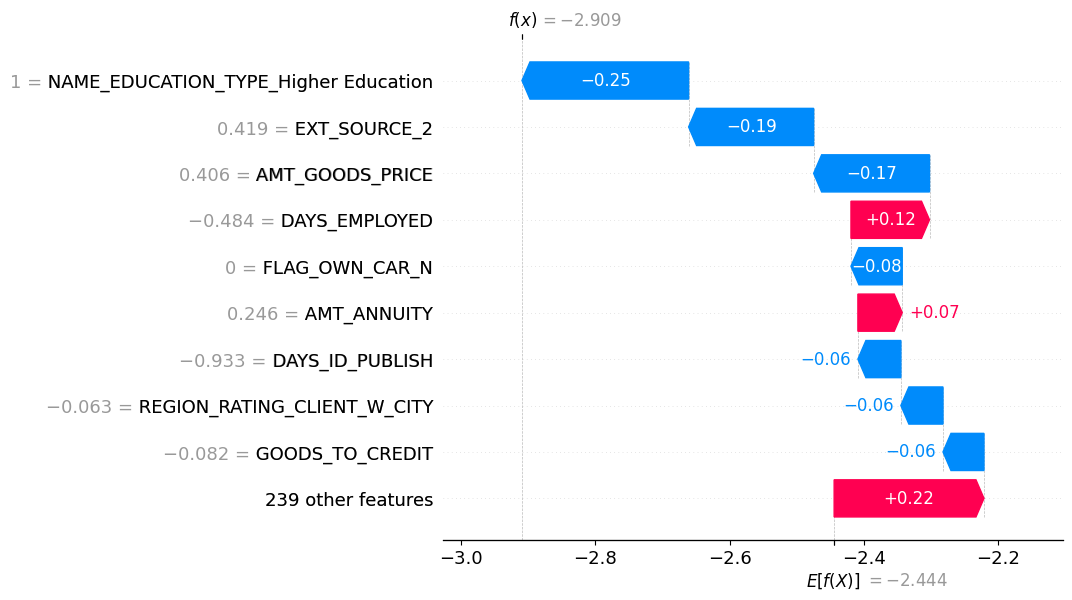

In [33]:
# LOCAL SHAP EXPLANATION

i = 0  # index of the borrower
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_transformed[i],
        feature_names=final_feature_names
    )
)


In [34]:
# SAVE TRAINED MODEL AND PREPROCESSOR


import joblib

# Save trained XGBoost pipeline
joblib.dump(
    xgb_model,
    "xgb_credit_risk_model.pkl"
)

# Save feature columns
joblib.dump(
    X.columns.tolist(),
    "model_features.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [35]:
# SAVE INPUT TEMPLATE

import joblib

empty_input = X.iloc[:1].copy()

joblib.dump(
    empty_input,
    "input_template.pkl"
)

print("Input template saved successfully.")

Input template saved successfully.
